# 02 — Modeling: preprocessing, classifiers, tuning, regression, deployment

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             mean_absolute_error, root_mean_squared_error, r2_score)
from sklearn.base import clone
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

def show_save(fig, name):
    fig.savefig(CHART_DIR / name, dpi=140)
    plt.show()
    plt.close(fig)
    print(f"-> charts/{name}")


In [2]:
# Continues from 01_eda: read the committed offline fallback -- NO second raw load.
df = pd.read_csv("titanic.csv")
print("read titanic.csv ->", df.shape)

y = df["survived"]
X = df[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]

n_surv, n_all = int(y.sum()), len(y)
print(f"class balance: survived = {n_surv} ({n_surv/n_all:.1%}) | "
      f"not survived = {n_all - n_surv} ({(n_all - n_surv)/n_all:.1%})")


read titanic.csv -> (891, 15)
class balance: survived = 342 (38.4%) | not survived = 549 (61.6%)


### Task 7 — Stratified train/test split (justification)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("train:", X_train.shape, " test:", X_test.shape)
print("train survived ratio:", round(y_train.mean(), 4),
      "| test survived ratio:", round(y_test.mean(), 4))


train: (712, 7)  test: (179, 7)
train survived ratio: 0.3834 | test survived ratio: 0.3855


### Task 8 — Preprocessing design (fit on TRAIN only, transform-only on TEST)

In [4]:
numeric_cols = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_cols = ["sex", "embarked"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scl", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first")),
        ]), categorical_cols),
    ],
    remainder="drop",
)
print("preprocessor defined — fitted only inside each pipeline on X_train.")


preprocessor defined — fitted only inside each pipeline on X_train.


### Task 9 — Train three classifiers on the *identical* split

In [5]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
}

pipes = {}
for name, clf in models.items():
    pipes[name] = Pipeline([("ct", preprocessor), ("clf", clf)])
    pipes[name].fit(X_train, y_train)      # preprocessor fits on TRAIN only
    print("fitted", name)

def evaluate(name, pipe):
    yp_tr = pipe.predict(X_train)
    yp = pipe.predict(X_test)
    yprob = pipe.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "train accuracy": round(accuracy_score(y_train, yp_tr), 4),
        "accuracy": round(accuracy_score(y_test, yp), 4),
        "precision": round(precision_score(y_test, yp), 4),
        "recall": round(recall_score(y_test, yp), 4),
        "F1": round(f1_score(y_test, yp), 4),
        "AUC": round(roc_auc_score(y_test, yprob), 4),
    }, confusion_matrix(y_test, yp)

results, cms = {}, {}
for name in pipes:
    results[name], cms[name] = evaluate(name, pipes[name])

cmp_tbl = pd.DataFrame(results.values()).set_index("model")
print("Classification comparison (test set):")
print(cmp_tbl.to_string())


fitted LogisticRegression
fitted DecisionTree


fitted RandomForest
Classification comparison (test set):
                    train accuracy  accuracy  precision  recall      F1     AUC
model                                                                          
LogisticRegression          0.8076    0.8045     0.7931  0.6667  0.7244  0.8435
DecisionTree                0.9831    0.8212     0.7937  0.7246  0.7576  0.7914
RandomForest                0.9831    0.8101     0.7778  0.7101  0.7424  0.8310


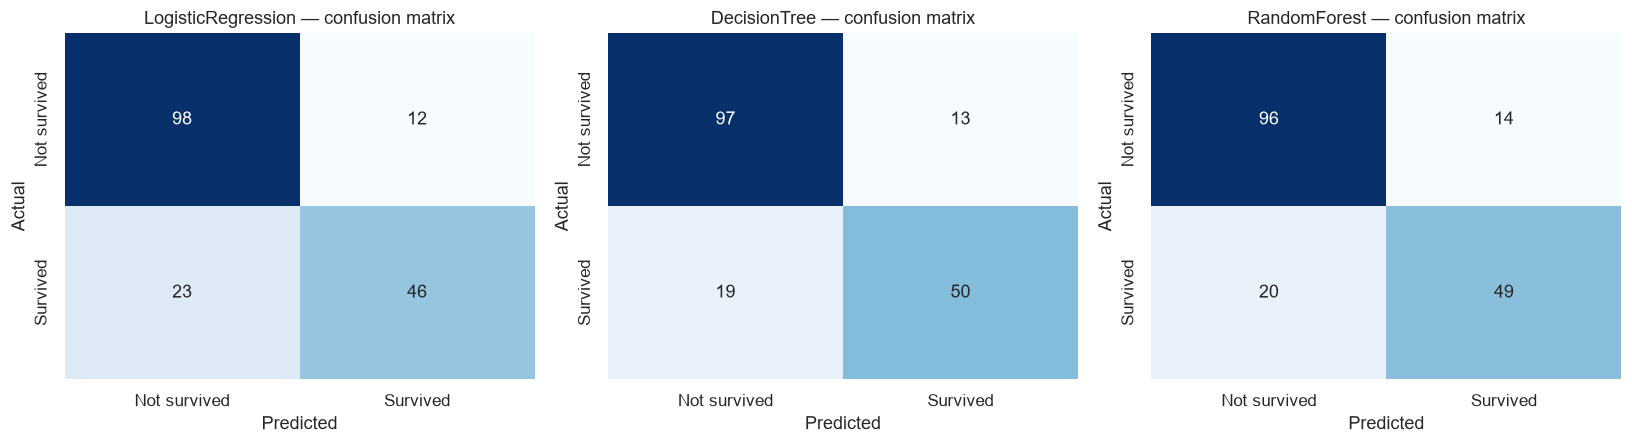

-> charts/confusion_matrices.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (name, cm) in zip(axes, cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Not survived", "Survived"],
                yticklabels=["Not survived", "Survived"], ax=ax)
    ax.set_title(f"{name} — confusion matrix")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
show_save(fig, "confusion_matrices.png")


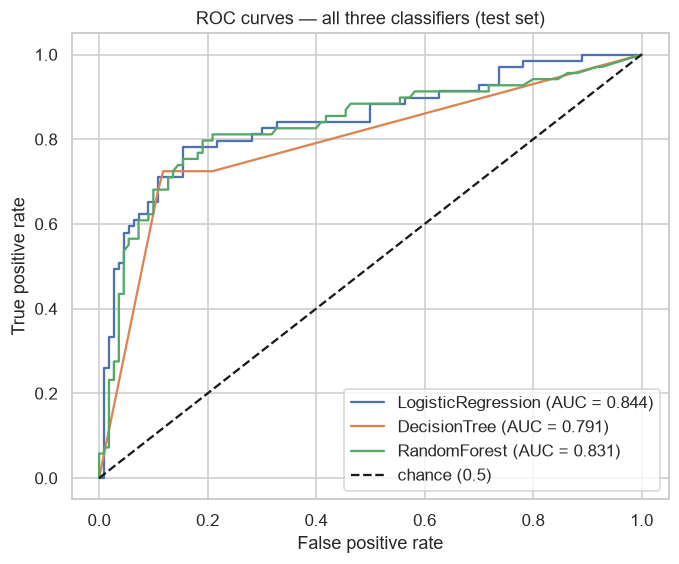

-> charts/roc_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for name in pipes:
    yprob = pipes[name].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, yprob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--", label="chance (0.5)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — all three classifiers (test set)")
ax.legend(loc="lower right")
show_save(fig, "roc_curves.png")


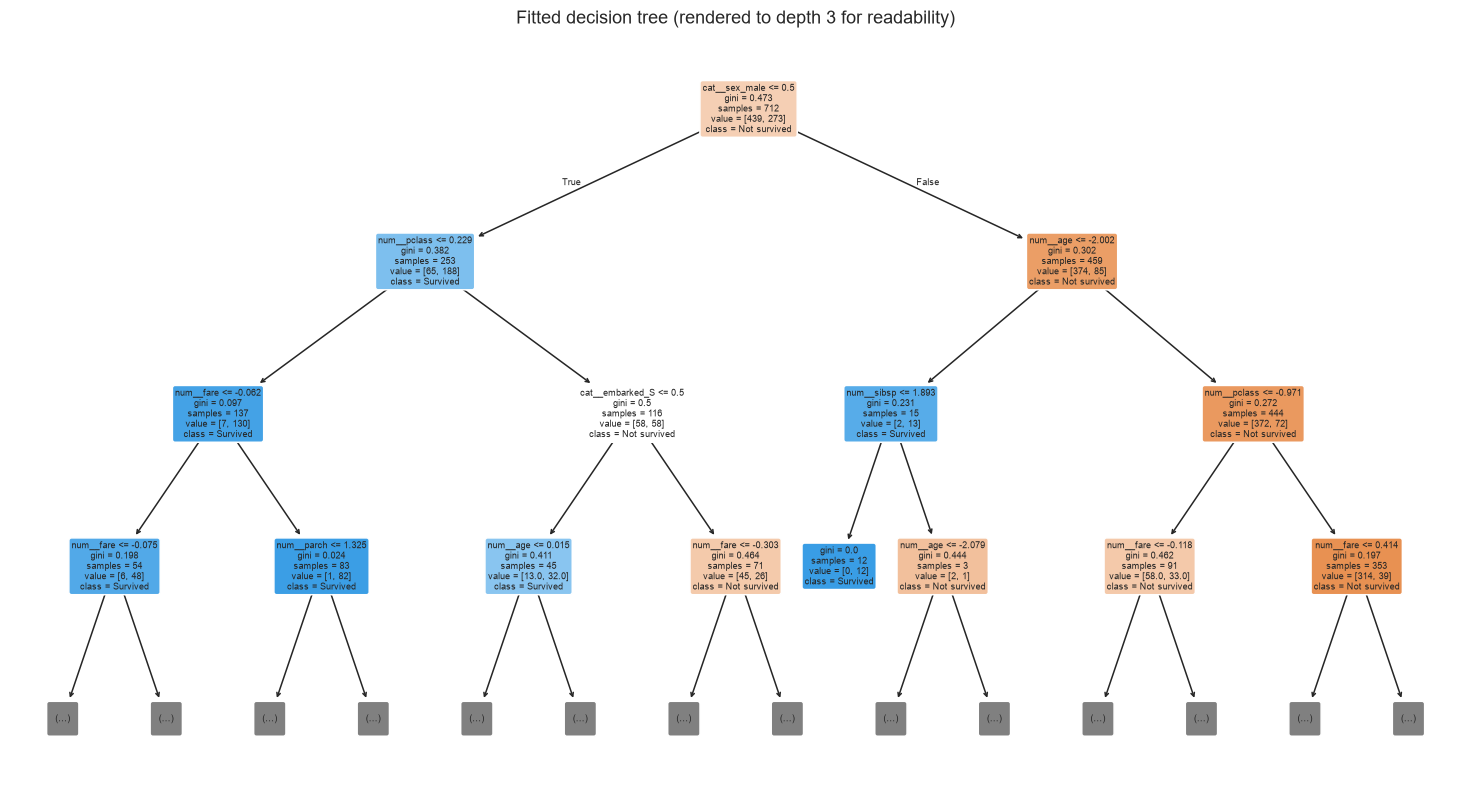

-> charts/decision_tree.png
feature names in transformed space: ['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S']


In [8]:
# Decision tree rendered with labeled feature & class names
dt_pipe = pipes["DecisionTree"]
feat_names = dt_pipe.named_steps["ct"].get_feature_names_out()
fig, ax = plt.subplots(figsize=(17, 9))
plot_tree(dt_pipe.named_steps["clf"],
          feature_names=feat_names,
          class_names=["Not survived", "Survived"],
          filled=True, rounded=True, max_depth=3, ax=ax)
ax.set_title("Fitted decision tree (rendered to depth 3 for readability)")
show_save(fig, "decision_tree.png")
print("feature names in transformed space:", list(feat_names))


In [ ]:
base = LogisticRegression(max_iter=2000, random_state=42)

variants = {
    "baseline": Pipeline([("ct", preprocessor), ("clf", clone(base))]),
    "class_weight='balanced'": Pipeline([("ct", preprocessor),
                                         ("clf", clone(base).set_params(class_weight="balanced"))]),
    "SMOTE (train-only)": ImbPipeline([("ct", preprocessor),
                                       ("smote", SMOTE(random_state=42)),
                                       ("clf", clone(base))]),
}

rows_imb = []
for label, pipe in variants.items():
    pipe.fit(X_train, y_train)              
    yp = pipe.predict(X_test)
    rows_imb.append({
        "variant": label,
        "precision": round(precision_score(y_test, yp), 4),
        "recall": round(recall_score(y_test, yp), 4),
        "F1": round(f1_score(y_test, yp), 4),
        "accuracy": round(accuracy_score(y_test, yp), 4),
    })
imbal_tbl = pd.DataFrame(rows_imb).set_index("variant")
print(imbal_tbl.to_string())


                         precision  recall      F1  accuracy
variant                                                     
baseline                    0.7931  0.6667  0.7244    0.8045
class_weight='balanced'     0.7297  0.7826  0.7552    0.8045
SMOTE (train-only)          0.7397  0.7826  0.7606    0.8101


### Task 11 — Hyperparameter tuning: GridSearchCV over Random Forest

We tune `n_estimators`, `max_depth` and `max_features` (5-fold CV, `roc_auc` scoring). The estimator is
constructed as `RandomForestClassifier(oob_score=True, ...)` **because `oob_score_` is only populated
when `oob_score=True` is passed at construction time** — otherwise the out-of-bag score would not exist to
report.


In [10]:
rf_oob = RandomForestClassifier(oob_score=True, random_state=42)

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [None, 7, 12],
    "clf__max_features": ["sqrt", "log2", None],
}
grid = GridSearchCV(Pipeline([("ct", preprocessor), ("clf", rf_oob)]),
                    param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print("best params       :", grid.best_params_)
print("best CV roc_auc   :", round(grid.best_score_, 4))
best_est = grid.best_estimator_                       # already refit on full X_train
print("OOB score (oob_score_) :", round(best_est.named_steps["clf"].oob_score_, 4))
print("tuned RF test AUC  :", round(roc_auc_score(y_test, best_est.predict_proba(X_test)[:, 1]), 4))
print("tuned RF test F1/acc:", round(f1_score(y_test, best_est.predict(X_test)), 4),
      "/", round(accuracy_score(y_test, best_est.predict(X_test)), 4))


best params       : {'clf__max_depth': 7, 'clf__max_features': 'sqrt', 'clf__n_estimators': 300}
best CV roc_auc   : 0.8711
OOB score (oob_score_) : 0.8287
tuned RF test AUC  : 0.8468
tuned RF test F1/acc: 0.7107 / 0.8045


### Task 12 — Regression side-task: predict `fare` from the other features

MAE          = 20.8094
RMSE         = 30.4731
R-squared    = 0.3999
Adjusted R2  = 0.3753   (n = 179, k = 7)


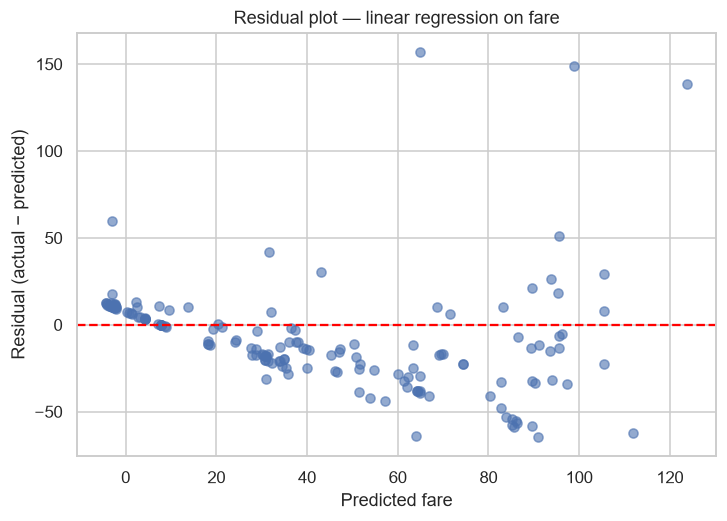

-> charts/residuals.png
median |resid|, low-predicted half : 10.4428
median |resid|, high-predicted half: 24.9654
corr(predicted, |resid|)           : 0.5478


In [11]:
Xr = df[["pclass", "sex", "age", "sibsp", "parch", "embarked"]]
yr = df["fare"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

reg_prep = ColumnTransformer(transformers=[
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scl", StandardScaler())]),
     ["pclass", "age", "sibsp", "parch"]),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first"))]),
     ["sex", "embarked"]),
], remainder="drop")

reg_pipe = Pipeline([("ct", reg_prep), ("lr", LinearRegression())])
reg_pipe.fit(Xr_train, yr_train)
y_pred_r = reg_pipe.predict(Xr_test)

mae = mean_absolute_error(yr_test, y_pred_r)
rmse = root_mean_squared_error(yr_test, y_pred_r)
r2 = r2_score(yr_test, y_pred_r)
n = len(yr_test)
k = reg_pipe.named_steps["ct"].fit_transform(Xr_train).shape[1]   # train-only again
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"MAE          = {mae:.4f}")
print(f"RMSE         = {rmse:.4f}")
print(f"R-squared    = {r2:.4f}")
print(f"Adjusted R2  = {adj_r2:.4f}   (n = {n}, k = {k})")

resid = yr_test.values - y_pred_r
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(y_pred_r, resid, alpha=0.6)
ax.axhline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Predicted fare"); ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residual plot — linear regression on fare")
show_save(fig, "residuals.png")

# Numeric check of spread vs. fitted value
low = y_pred_r <= np.median(y_pred_r); high = ~low
print("median |resid|, low-predicted half :", round(float(np.median(np.abs(resid[low]))), 4))
print("median |resid|, high-predicted half:", round(float(np.median(np.abs(resid[high]))), 4))
print("corr(predicted, |resid|)           :", round(float(np.corrcoef(y_pred_r, np.abs(resid))[0, 1]), 4))


### Task 13 — Final comparison tables & recommendation

Classification metrics and regression metrics live on **different scales** and are **not directly
comparable**, so they are presented as two distinct metric groups — one per model type — in separate
columns.


In [12]:
classifier_table = pd.DataFrame(results.values()).set_index("model").T
print("CLASSIFIERS (test set) — group 1:")
print(classifier_table.to_string())

reg_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R-squared", "Adjusted R-squared"],
    "value": [round(mae, 4), round(rmse, 4), round(r2, 4), round(adj_r2, 4)],
}).set_index("metric")
print("\nREGRESSION — predict fare (test set) — group 2:")
print(reg_metrics.to_string())

print("\n(The two groups are on different scales and are deliberately NOT merged.)")


CLASSIFIERS (test set) — group 1:
model           LogisticRegression  DecisionTree  RandomForest
train accuracy              0.8076        0.9831        0.9831
accuracy                    0.8045        0.8212        0.8101
precision                   0.7931        0.7937        0.7778
recall                      0.6667        0.7246        0.7101
F1                          0.7244        0.7576        0.7424
AUC                         0.8435        0.7914        0.8310

REGRESSION — predict fare (test set) — group 2:
                      value
metric                     
MAE                 20.8094
RMSE                30.4731
R-squared            0.3999
Adjusted R-squared   0.3753

(The two groups are on different scales and are deliberately NOT merged.)


In [ ]:
best_est = grid.best_estimator_     # tuned RandomForest (best CV AUC 0.8711, OOB 0.8287)
print("deploying tuned RandomForest pipeline")

joblib.dump(best_est, "pipeline_best.joblib")
print("-> pipeline_best.joblib written (preprocessor + tuned RF as one object)")

# --- reload & verify --------------------------------------------------------
loaded = joblib.load("pipeline_best.joblib")

raw_rows = X_test.iloc[:5].copy()                     # raw input rows, exactly as read from csv
same = bool(np.array_equal(loaded.predict(raw_rows), best_est.predict(raw_rows)))
print("identical predictions after reload on identical raw rows:", same)

noisy = X_test.iloc[:5].copy()
noisy.loc[noisy.index[:2], "age"] = np.nan            # inject missing age as fresh raw data would
preds = loaded.predict(noisy)
print("predictions on raw rows with missing age (imputed inside pipeline):", preds)
print("survival probabilities on the 5 raw rows:", loaded.predict_proba(raw_rows)[:, 1].round(4))


deploying tuned RandomForest pipeline
-> pipeline_best.joblib written (preprocessor + tuned RF as one object)


identical predictions after reload on identical raw rows: True
predictions on raw rows with missing age (imputed inside pipeline): [0 0 0 0 1]
survival probabilities on the 5 raw rows: [0.1259 0.1869 0.1427 0.0898 0.6892]
